In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("/content/realistic_e_commerce_sales_data.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Dataset shape: (1000, 12)


,Customer ID,Gender,Region,Age,Product Name,Category,Unit Price,Quantity,Total Price,Shipping Fee,Shipping Status,Order Date
0,CUST0268,Male,North,NaN,Monitor,Electronics,300.0,5,1500,13.31,Returned,2023-12-08
1,CUST0046,Male,West,22.0,Headphones,Accessories,100.0,2,200,6.93,In Transit,2023-04-09
2,CUST0169,Female,South,54.0,Monitor,Electronics,300.0,1,300,11.31,Returned,2023-08-28
3,CUST0002,Male,North,23.0,Headphones,Accessories,100.0,5,500,12.22,Delivered,2023-01-18
4,CUST0173,Female,South,NaN,Laptop,Electronics,1500.0,3,4500,5.40,Delivered,2023-01-19


In [15]:
# Basic Dataset Inspection

print("Column Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nDataset Shape:")
print(df.shape)

Column Names:
['Customer ID', 'Gender', 'Region', 'Age', 'Product Name', 'Category', 'Unit Price', 'Quantity', 'Total Price', 'Shipping Fee', 'Shipping Status', 'Order Date']

Data Types:
Customer ID         object
Gender              object
Region              object
Age                float64
Product Name        object
Category            object
Unit Price         float64
Quantity             int64
Total Price          int64
Shipping Fee       float64
Shipping Status     object
Order Date          object
dtype: object

Missing Values:
Customer ID          0
Gender               0
Region              50
Age                100
Product Name         0
Category             0
Unit Price           0
Quantity             0
Total Price          0
Shipping Fee         0
Shipping Status     50
Order Date           0
dtype: int64

Duplicate Rows:
0

Dataset Shape:
(1000, 12)


# Task 1: Exploratory Data Analysis on E-Commerce Sales Data

## Objective
The objective of this analysis is to perform a comprehensive Exploratory Data Analysis (EDA) on an e-commerce sales dataset to identify sales patterns, customer behaviour trends, product performance, and actionable business insights.

### Key Areas of Analysis
- Dataset structure and data quality
- Descriptive statistics
- Monthly and quarterly sales trends
- Customer demographics
- Best-selling products
- Revenue by product category
- Correlation between numerical variables
- Additional business insights
- Actionable recommendations

In [16]:
# =========================
# DATA CLEANING
# =========================

# Create a copy so the original dataframe remains unchanged
data = df.copy()

# Remove leading/trailing spaces from column names
data.columns = data.columns.str.strip()

# Convert Order Date to datetime
data['Order Date'] = pd.to_datetime(data['Order Date'], errors='coerce')

# Check missing values before handling them
print("Missing values before cleaning:")
print(data.isnull().sum())

# Fill missing Region values with the most frequent region
data['Region'] = data['Region'].fillna(data['Region'].mode()[0])

# Fill missing Age values with the median age
data['Age'] = data['Age'].fillna(data['Age'].median())

# Check duplicates
duplicate_count = data.duplicated().sum()

print("\nDuplicate rows:", duplicate_count)

# Remove duplicate rows if present
data = data.drop_duplicates()

# Final missing-value check
print("\nMissing values after cleaning:")
print(data.isnull().sum())

print("\nFinal dataset shape:", data.shape)

Missing values before cleaning:
Customer ID          0
Gender               0
Region              50
Age                100
Product Name         0
Category             0
Unit Price           0
Quantity             0
Total Price          0
Shipping Fee         0
Shipping Status     50
Order Date           0
dtype: int64

Duplicate rows: 0

Missing values after cleaning:
Customer ID         0
Gender              0
Region              0
Age                 0
Product Name        0
Category            0
Unit Price          0
Quantity            0
Total Price         0
Shipping Fee        0
Shipping Status    50
Order Date          0
dtype: int64

Final dataset shape: (1000, 12)


In [17]:
# =========================
# DESCRIPTIVE STATISTICS
# =========================

numerical_columns = data.select_dtypes(include=np.number).columns

print("Mean:")
display(data[numerical_columns].mean())

print("\nMedian:")
display(data[numerical_columns].median())

print("\nMode:")
display(data[numerical_columns].mode().iloc[0])

print("\nStandard Deviation:")
display(data[numerical_columns].std())

print("\nComplete Descriptive Statistics:")
display(data[numerical_columns].describe())

Mean:


,0
Age,46.926000
Unit Price,457.703777
Quantity,3.008000
Total Price,1346.600000
Shipping Fee,12.416390



Median:


,0
Age,49.000
Unit Price,200.000
Quantity,3.000
Total Price,600.000
Shipping Fee,12.315



Mode:


,0
Age,49.00
Unit Price,300.00
Quantity,3.00
Total Price,200.00
Shipping Fee,9.26



Standard Deviation:


,0
Age,14.257061
Unit Price,537.231434
Quantity,1.404246
Total Price,1834.037877
Shipping Fee,4.412185



Complete Descriptive Statistics:


,Age,Unit Price,Quantity,Total Price,Shipping Fee
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,46.926000,457.703777,3.008000,1346.600000,12.416390
std,14.257061,537.231434,1.404246,1834.037877,4.412185
min,18.000000,30.000000,1.000000,30.000000,5.000000
25%,37.000000,50.000000,2.000000,200.000000,8.560000
50%,49.000000,200.000000,3.000000,600.000000,12.315000
75%,58.000000,800.000000,4.000000,1500.000000,16.075000
max,69.000000,3109.560612,5.000000,7500.000000,19.980000


## Monthly Sales Trend

The monthly sales trend helps identify changes in sales performance over time and highlights periods of relatively high or low revenue.

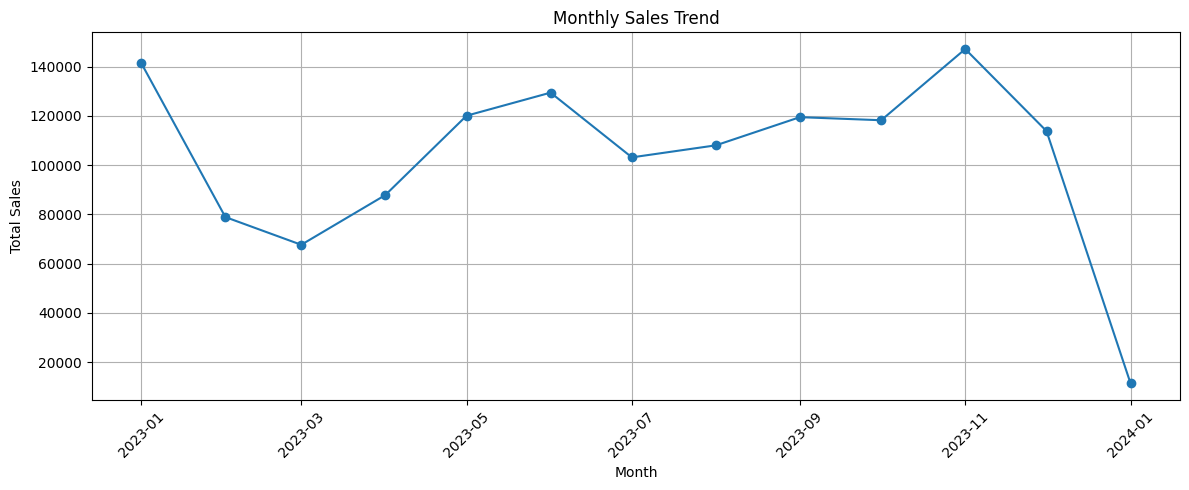

In [18]:
# =========================
# MONTHLY SALES TREND
# =========================

monthly_sales = (
    data.groupby(data['Order Date'].dt.to_period('M'))['Total Price']
    .sum()
    .reset_index()
)

monthly_sales['Order Date'] = monthly_sales['Order Date'].dt.to_timestamp()

plt.figure(figsize=(12, 5))
plt.plot(
    monthly_sales['Order Date'],
    monthly_sales['Total Price'],
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

### Observation
The monthly sales trend shows how revenue changes over time. Peaks indicate stronger sales periods, while lower points indicate weaker periods. These patterns can help businesses plan inventory, promotions, and marketing campaigns.

## Quarterly Sales Trend

Quarterly analysis provides a broader view of sales performance and helps identify seasonal patterns across the year.

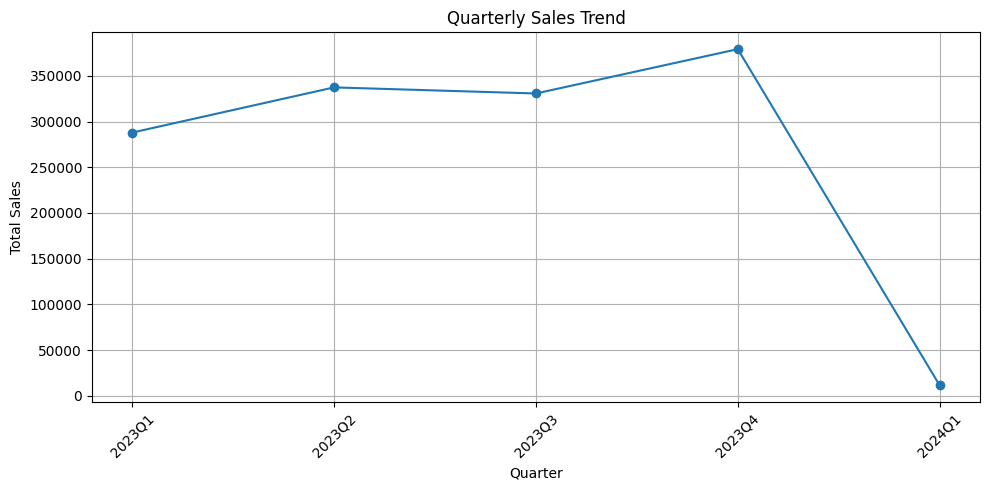

In [19]:
# =========================
# QUARTERLY SALES TREND
# =========================

quarterly_sales = (
    data.groupby(data['Order Date'].dt.to_period('Q'))['Total Price']
    .sum()
    .reset_index()
)

quarterly_sales['Order Date'] = quarterly_sales['Order Date'].astype(str)

plt.figure(figsize=(10, 5))
plt.plot(
    quarterly_sales['Order Date'],
    quarterly_sales['Total Price'],
    marker='o'
)

plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

### Observation
The quarterly sales analysis provides a high-level view of revenue performance. Comparing quarters helps identify periods of stronger demand and supports better business planning.

## Customer Demographic Analysis

Understanding customer demographics helps businesses identify their major customer groups and develop more targeted marketing strategies.

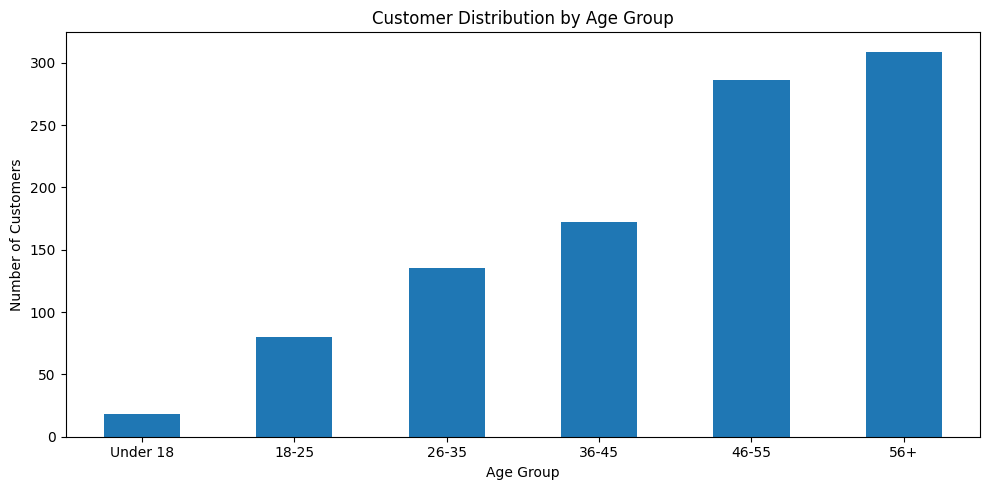

In [20]:
# =========================
# AGE GROUP ANALYSIS
# =========================

data['Age Group'] = pd.cut(
    data['Age'],
    bins=[0, 18, 25, 35, 45, 55, 100],
    labels=[
        'Under 18',
        '18-25',
        '26-35',
        '36-45',
        '46-55',
        '56+'
    ]
)

age_group_counts = data['Age Group'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
age_group_counts.plot(kind='bar')

plt.title('Customer Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Observation
The age-group distribution shows which customer age ranges are most represented in the dataset. This information can support age-specific marketing and product strategies.

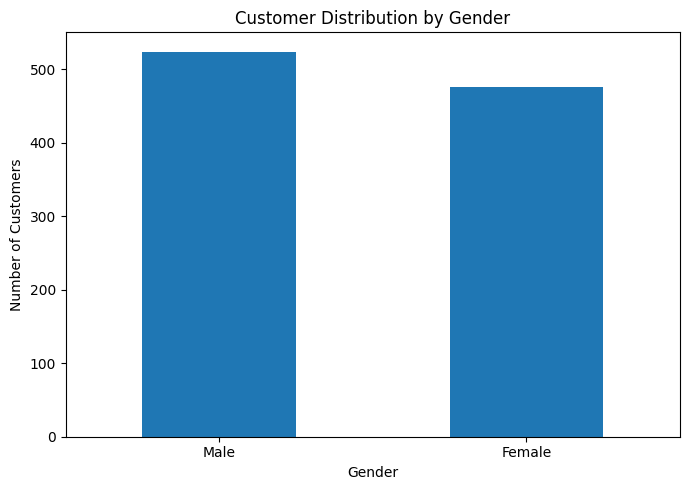

In [21]:
# =========================
# GENDER ANALYSIS
# =========================

gender_counts = data['Gender'].value_counts()

plt.figure(figsize=(7, 5))
gender_counts.plot(kind='bar')

plt.title('Customer Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Observation
The gender distribution provides an overview of the customer base and can help businesses understand whether their sales are relatively balanced or concentrated among particular customer groups.

## Top 10 Best-Selling Products

This analysis identifies the products with the highest total quantity sold. It helps the business understand which products are most popular among customers.

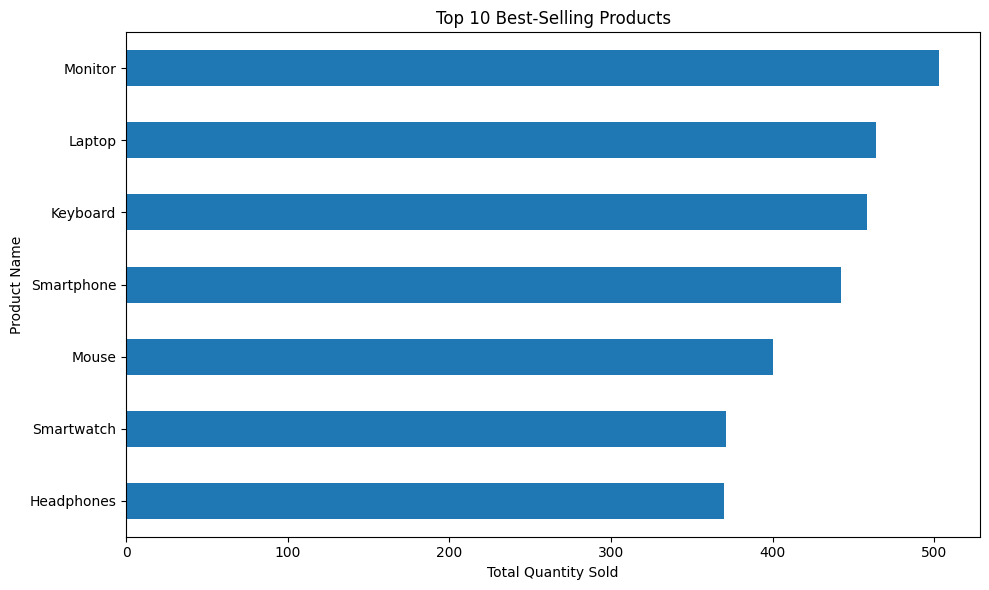

,Total Quantity Sold
Product Name,
Monitor,503
Laptop,464
Keyboard,458
Smartphone,442
Mouse,400
Smartwatch,371
Headphones,370


In [22]:
# =========================
# TOP 10 BEST-SELLING PRODUCTS
# =========================

top_products = (
    data.groupby('Product Name')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
top_products.sort_values().plot(kind='barh')

plt.title('Top 10 Best-Selling Products')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product Name')
plt.tight_layout()
plt.show()

display(top_products.to_frame('Total Quantity Sold'))

### Observation

The chart highlights the 10 products with the highest sales volume. These products represent the most popular items in terms of quantity sold and can be prioritized for inventory planning and promotional campaigns.

## Revenue by Product Category

This analysis compares total revenue generated by different product categories to identify the strongest revenue-generating categories.

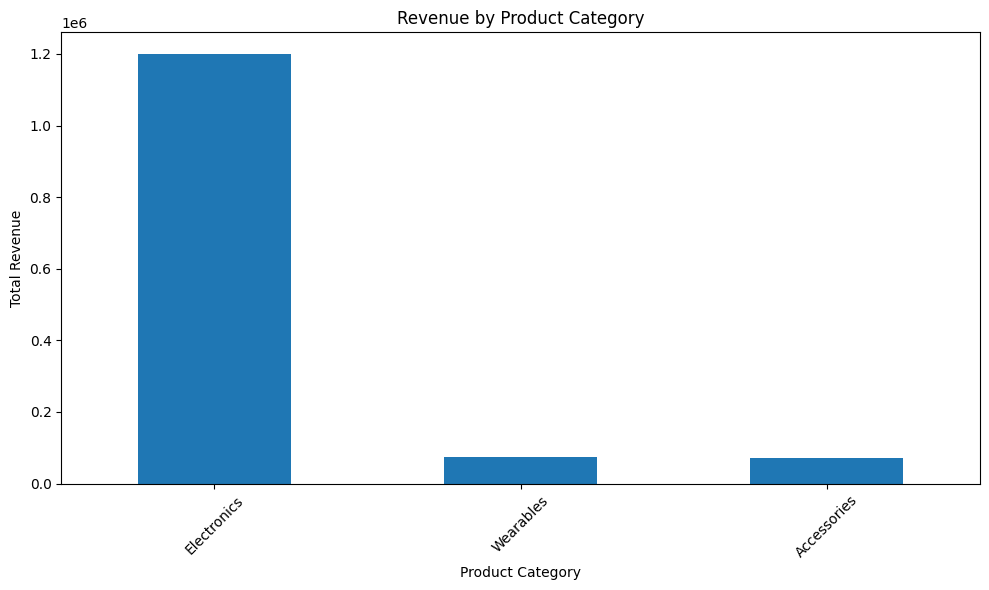

,Total Revenue
Category,
Electronics,1200500
Wearables,74200
Accessories,71900


In [23]:
# =========================
# REVENUE BY PRODUCT CATEGORY
# =========================

category_revenue = (
    data.groupby('Category')['Total Price']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
category_revenue.plot(kind='bar')

plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display(category_revenue.to_frame('Total Revenue'))

### Observation

The category-level revenue comparison shows which product categories contribute the most to overall sales revenue. Higher-performing categories can receive greater inventory attention, while lower-performing categories may require promotional strategies.

## Correlation Analysis

A correlation heatmap is used to understand relationships between numerical variables such as age, unit price, quantity, total price, and shipping fee.

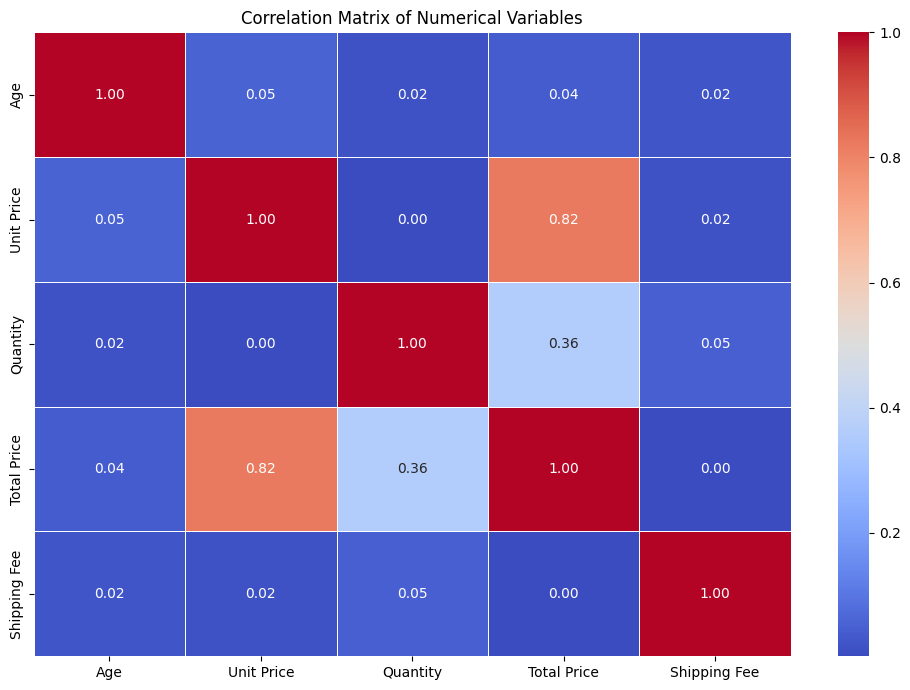

In [24]:
# =========================
# CORRELATION HEATMAP
# =========================

numeric_data = data.select_dtypes(include=np.number)

correlation_matrix = numeric_data.corr()

plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Matrix of Numerical Variables')
plt.tight_layout()
plt.show()

### Observation

The correlation matrix shows the strength and direction of relationships between numerical variables. Strong positive or negative relationships may indicate variables that move together and can provide useful business insights.

## Additional Insight: Average Order Value by Gender

Average order value helps compare purchasing value across customer groups. This can reveal differences that may not be visible from customer counts alone.

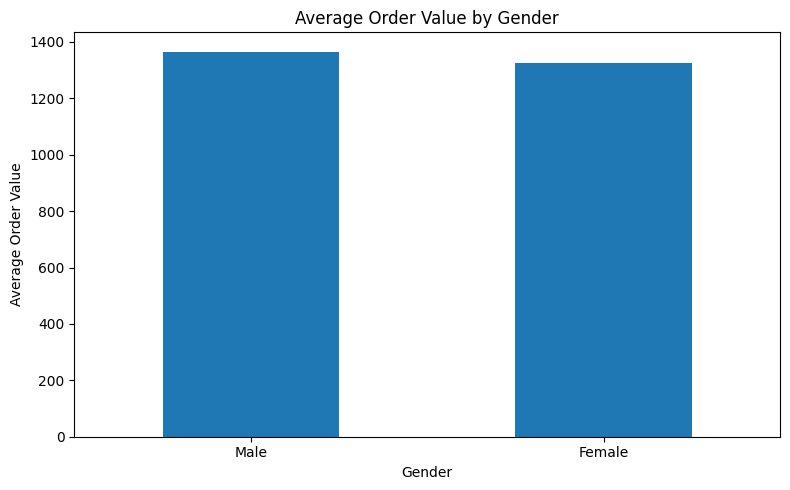

,Average Order Value
Gender,
Male,1365.629771
Female,1325.651261


In [25]:
# =========================
# AVERAGE ORDER VALUE BY GENDER
# =========================

avg_order_gender = (
    data.groupby('Gender')['Total Price']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
avg_order_gender.plot(kind='bar')

plt.title('Average Order Value by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Order Value')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

display(avg_order_gender.to_frame('Average Order Value'))

### Observation

Comparing average order value by gender provides an additional perspective beyond simply counting customers. A customer group with fewer customers may still generate a relatively high average order value, which can help businesses design more targeted marketing strategies.

In [26]:
# =========================
# FINAL KEY FINDINGS
# =========================

# 1. Date range
print("DATE RANGE")
print("Start:", data['Order Date'].min().date())
print("End:", data['Order Date'].max().date())

# 2. Total sales
print("\nTOTAL SALES")
print(f"{data['Total Price'].sum():,.2f}")

# 3. Highest sales month
monthly = data.groupby(
    data['Order Date'].dt.to_period('M')
)['Total Price'].sum()

print("\nHIGHEST SALES MONTH")
print(monthly.idxmax(), "→", f"{monthly.max():,.2f}")

# 4. Lowest sales month
print("\nLOWEST SALES MONTH")
print(monthly.idxmin(), "→", f"{monthly.min():,.2f}")

# 5. Best-selling product
products = data.groupby('Product Name')['Quantity'].sum().sort_values(ascending=False)

print("\nTOP 3 BEST-SELLING PRODUCTS")
print(products.head(3))

# 6. Best revenue category
categories = data.groupby('Category')['Total Price'].sum().sort_values(ascending=False)

print("\nTOP REVENUE CATEGORIES")
print(categories.head(3))

# 7. Largest age group
age_groups = data['Age Group'].value_counts()

print("\nLARGEST AGE GROUP")
print(age_groups.idxmax(), "→", age_groups.max(), "customers")

# 8. Gender distribution
print("\nGENDER DISTRIBUTION")
print(data['Gender'].value_counts())

# 9. Average order value
print("\nAVERAGE ORDER VALUE")
print(f"{data['Total Price'].mean():,.2f}")

# 10. Highest average order value by gender
gender_aov = data.groupby('Gender')['Total Price'].mean().sort_values(ascending=False)

print("\nAVERAGE ORDER VALUE BY GENDER")
print(gender_aov)

DATE RANGE
Start: 2023-01-01
End: 2024-01-03

TOTAL SALES
1,346,600.00

HIGHEST SALES MONTH
2023-11 → 147,150.00

LOWEST SALES MONTH
2024-01 → 11,380.00

TOP 3 BEST-SELLING PRODUCTS
Product Name
Monitor     503
Laptop      464
Keyboard    458
Name: Quantity, dtype: int64

TOP REVENUE CATEGORIES
Category
Electronics    1200500
Wearables        74200
Accessories      71900
Name: Total Price, dtype: int64

LARGEST AGE GROUP
56+ → 309 customers

GENDER DISTRIBUTION
Gender
Male      524
Female    476
Name: count, dtype: int64

AVERAGE ORDER VALUE
1,346.60

AVERAGE ORDER VALUE BY GENDER
Gender
Male      1365.629771
Female    1325.651261
Name: Total Price, dtype: float64
